Projekt System Rekomendacji

MovieLens Latest Dataset small

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

movie_ratings = pd.merge(ratings, movies, on='movieId')

In [174]:
print(f"Załadowano {len(movie_ratings)} ocen.")
print(movie_ratings.head())

Załadowano 100836 ocen.
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


Które filmy są najczęściej oceniane

      movieId  rating_count                             title
314       356           329               Forrest Gump (1994)
277       318           317  Shawshank Redemption, The (1994)
257       296           307               Pulp Fiction (1994)
510       593           279  Silence of the Lambs, The (1991)
1938     2571           278                Matrix, The (1999)


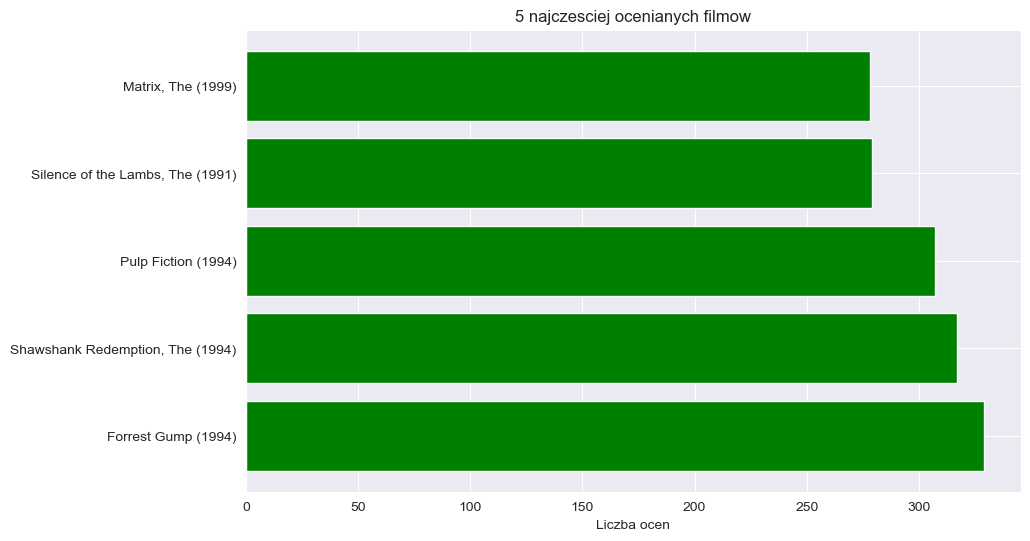

In [175]:
ratings_counts = movie_ratings.groupby('movieId').size()

top_movies = pd.DataFrame({
    'movieId':ratings_counts.index,
    'rating_count':ratings_counts.values
}).merge(movies[['movieId', 'title']], on='movieId')

top_movies = top_movies.sort_values('rating_count', ascending=False)

print(top_movies.head(5))
top = top_movies.head(5)

plt.figure(figsize=(10,6))
bars = plt.barh(top['title'], top['rating_count'], color='green')
plt.xlabel('Liczba ocen')
plt.title('5 najczesciej ocenianych filmow')
plt.show()

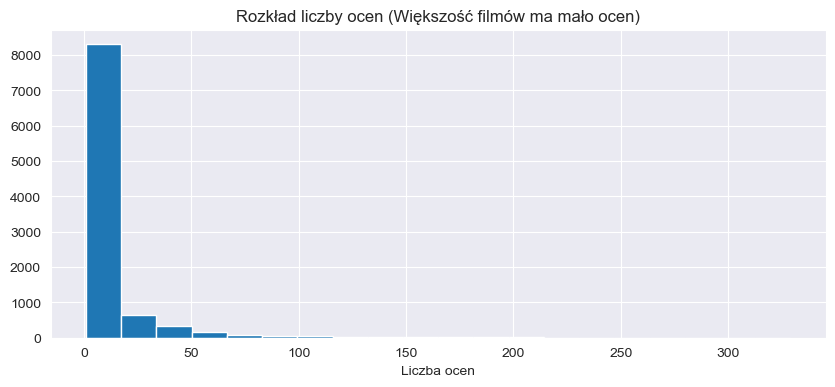

In [176]:
plt.figure(figsize=(10,4))
top_movies['rating_count'].hist(bins=20)
plt.title('Rozkład liczby ocen (Większość filmów ma mało ocen)')
plt.xlabel('Liczba ocen')
plt.show()

Stworz macierz, wiersze userId, kolumny moviesId, wartosci to rating

In [177]:
user_rating_matrix = movie_ratings.pivot_table(
    index='userId',
    columns='title',#columns='movieId',
    values='rating'#, fill_value=0
)

print(user_rating_matrix.head())

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1              NaN                                      NaN   
2              NaN                                      NaN   
3              NaN                                      NaN   
4              NaN                                      NaN   
5              NaN                                      NaN   

title   'Round Midnight (1986)  'Salem's Lot (2004)  \
userId                                                
1                          NaN                  NaN   
2                          NaN                  NaN   
3                          NaN                  NaN   
4                          NaN                  NaN   
5                          NaN                  NaN   

title   'Til There Was You (1997)  'Tis the Season for Love (2015)  \
userId                                                               
1                             Na

pokazywanie rekomendacji danego filmu (zwraca filmy skorelowane z danymi)

In [178]:
def getRecomendation(movie_title, min_ratings=50):
    #Funkcja zwraca filmy skorelowane z podanym tytułem. Args: movie_title (str): Tytuł filmu, np. 'Star Wars (1977)' min_ratings (int): Minimalna liczba ocen, jaką musi mieć film, by był brany pod uwagę (odrzucamy niszowe)

    # # Sprawdzenie czy film istnieje w bazie
    # if movie_title not in user_rating_matrix.columns:
    #     return "Film nie znaleziony"
    # user_ratings = user_rating_matrix[movie_title]

    # 1. Pobieramy oceny użytkowników dla konkretnego filmu
    try:
        user_ratings = user_rating_matrix[movie_title]
    except KeyError:
            return "Film nie znaleziony w bazie."

    # 2. Obliczamy korelację tego filmu ze WSZYSTKIMI innymi filmami w macierzy # Metoda corrwith jest tutaj kluczowa - liczy korelację parami
    similar_movies = user_rating_matrix.corrwith(user_ratings, method='pearson')

    # 3. Tworzenie DataFrame z wynikami
    corr_df = pd.DataFrame(similar_movies, columns=['correlation'])

    # 4. Usuwamy puste wartości (tam gdzie nie było wspólnych użytkowników)
    corr_df.dropna(inplace=True)

    # Dodanie liczby ocen dla każdego filmu
    top_movies_for_join = top_movies.set_index('title')
    corr_df = corr_df.join(top_movies_for_join['rating_count'])

    # Filtrowanie i sortowanie
    recommendations = corr_df[corr_df['rating_count'] > min_ratings].sort_values('correlation', ascending=False)

    # Usunięcie filmu, dla którego szukamy rekomendacji
    recommendations = recommendations.drop(movie_title, errors='ignore')

    return recommendations.head(10)

In [179]:
print(getRecomendation("Jumanji (1995)"))

D:\Programy\_Coding\Miniconda3\envs\Env1\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
D:\Programy\_Coding\Miniconda3\envs\Env1\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
D:\Programy\_Coding\Miniconda3\envs\Env1\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
D:\Programy\_Coding\Miniconda3\envs\Env1\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\Programy\_Coding\Miniconda3\envs\Env1\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                            correlation  rating_count
title                                                
Notting Hill (1999)            0.798372            56
Million Dollar Baby (2004)     0.716712            52
Others, The (2001)             0.698576            55
Donnie Brasco (1997)           0.687060            52
Social Network, The (2010)     0.673058            57
First Knight (1995)            0.669709            54
Liar Liar (1997)               0.659437            74
Chinatown (1974)               0.656153            59
King's Speech, The (2010)      0.656139            58
Dragonheart (1996)             0.634676            65
